In [1]:
from google import genai
from google.genai import types
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import umap
from datasets import load_dataset
import pacmap
import random
random.seed(42)

/Volumes/Crucial X9/knowledge-gaps/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds = load_dataset("qwedsacf/competition_math")

client = genai.Client()

print(len(ds['train']))

In [ ]:
indices = random.sample(range(len(ds['train'])), 99)

texts = [ds['train']['problem'][i] for i in indices]
colors_type = [ds['train']['type'][i] for i in indices]
colors_level = [ds['train']['level'][i] for i in indices]

In [5]:
result = [
    np.array(e.values) for e in client.models.embed_content(
        model="gemini-embedding-001",
        contents=texts,
        config=types.EmbedContentConfig(task_type="CLUSTERING")).embeddings
]

embeddings_matrix = np.array(result)
similarity_matrix = cosine_similarity(embeddings_matrix)

for i, text1 in enumerate(texts):
    for j in range(i + 1, len(texts)):
        text2 = texts[j]
        similarity = similarity_matrix[i, j]
        print(f"Similarity between '{text1}' and '{text2}': {similarity:.4f}")

Similarity between 'Find the least positive integer $k$ for which the equation $\left\lfloor\frac{2002}{n}\right\rfloor=k$ has no integer solutions for $n$. (The notation $\lfloor x\rfloor$ means the greatest integer less than or equal to $x$.)' and '$n$ coins are simultaneously flipped.  The probability that at most one of them shows tails is $\frac{3}{16}$.  Find $n$.': 0.8020
Similarity between 'Find the least positive integer $k$ for which the equation $\left\lfloor\frac{2002}{n}\right\rfloor=k$ has no integer solutions for $n$. (The notation $\lfloor x\rfloor$ means the greatest integer less than or equal to $x$.)' and 'For which positive integer values of $k$ does $kx^2+20x+k=0$ have rational solutions? Express your answers separated by commas and in increasing order.': 0.8473
Similarity between 'Find the least positive integer $k$ for which the equation $\left\lfloor\frac{2002}{n}\right\rfloor=k$ has no integer solutions for $n$. (The notation $\lfloor x\rfloor$ means the greate

### UMAP

In [8]:
unique_types = list(set(colors_type)) # colors_level
color_map = {type_name: i for i, type_name in enumerate(unique_types)}
color_values = [color_map[c] for c in colors_type] # colors_level

/Users/shreyanakum/Documents/knowledge-gaps/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


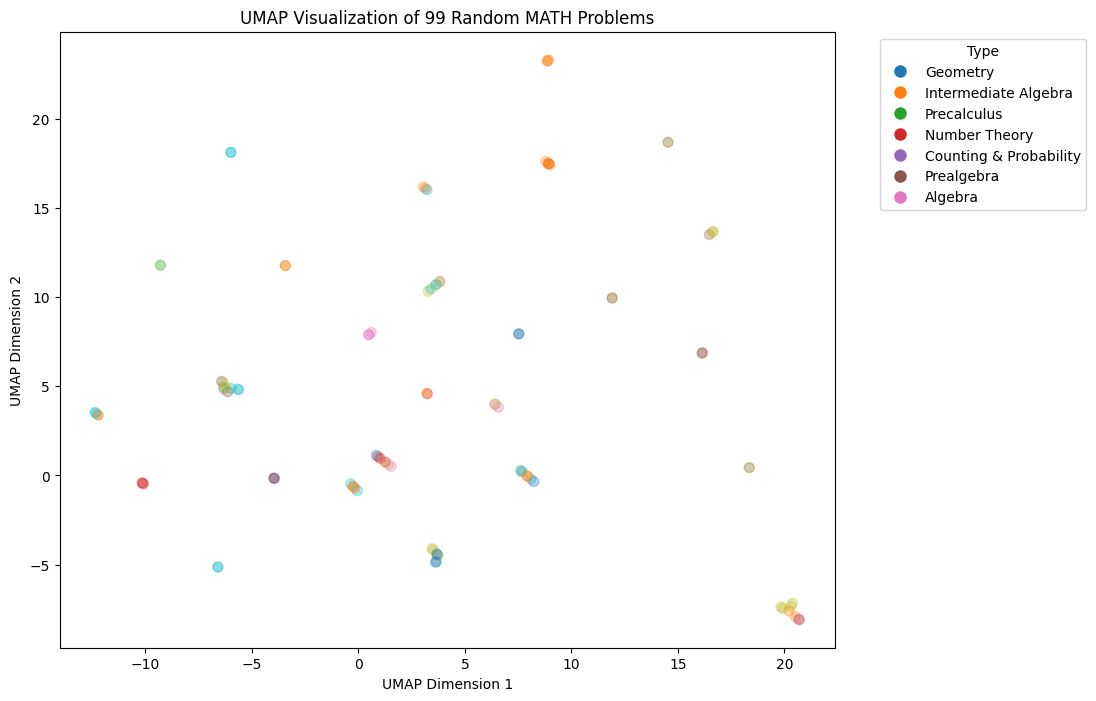

In [9]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=2, min_dist=0.1, init='random')
embeddings_2d = reducer.fit_transform(embeddings_matrix)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=color_values, s=50, alpha=0.3, cmap='tab10')

for i, txt in enumerate(texts):
    plt.annotate(txt[:0], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of 99 Random MATH Problems')
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=plt.cm.tab10(color_map[t]), 
                      markersize=10, label=t) 
           for t in unique_types]
plt.legend(handles=handles, title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig("./umap_colors_level.png")

### PaCMAP

In [10]:
np.shape(embeddings_matrix)

(99, 3072)

In [11]:
# initializing the pacmap instance
# Setting n_neighbors to "None" leads to an automatic choice shown below in "parameter" section
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0) 

X = embeddings_matrix.reshape(embeddings_matrix.shape[0], -1)

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(X, init="pca")

# visualize the embedding
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], cmap="Spectral", s=20)

ValueError: could not broadcast input array from shape (0,) into shape (60,)